# 1. 라이브러리

In [47]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 2. 데이터셋 로드

In [48]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values="?")

/tmp/ipykernel_5586/3572812855.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values="?")


# 3. 데이터 전처리

In [49]:
df = df.dropna()
df = df.drop(columns=['car_name'])

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [50]:
# X(특성)와 y(타겟: mpg 연비) 분리

X = df.drop(columns=['mpg']).values
y = df['mpg'].values

(X, y)

(array([[  8. , 307. , 130. , ...,  12. ,  70. ,   1. ],
        [  8. , 350. , 165. , ...,  11.5,  70. ,   1. ],
        [  8. , 318. , 150. , ...,  11. ,  70. ,   1. ],
        ...,
        [  4. , 135. ,  84. , ...,  11.6,  82. ,   1. ],
        [  4. , 120. ,  79. , ...,  18.6,  82. ,   1. ],
        [  4. , 119. ,  82. , ...,  19.4,  82. ,   1. ]]),
 array([18. , 15. , 18. , 16. , 17. , 15. , 14. , 14. , 14. , 15. , 15. ,
        14. , 15. , 14. , 24. , 22. , 18. , 21. , 27. , 26. , 25. , 24. ,
        25. , 26. , 21. , 10. , 10. , 11. ,  9. , 27. , 28. , 25. , 19. ,
        16. , 17. , 19. , 18. , 14. , 14. , 14. , 14. , 12. , 13. , 13. ,
        18. , 22. , 19. , 18. , 23. , 28. , 30. , 30. , 31. , 35. , 27. ,
        26. , 24. , 25. , 23. , 20. , 21. , 13. , 14. , 15. , 14. , 17. ,
        11. , 13. , 12. , 13. , 19. , 15. , 13. , 13. , 14. , 18. , 22. ,
        21. , 26. , 22. , 28. , 23. , 28. , 27. , 13. , 14. , 13. , 14. ,
        15. , 12. , 13. , 13. , 14. , 13. , 12. , 1

In [60]:
# 데이터 표준화 (StandardScaler)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X

array([[ 1.48394702,  1.07728956,  0.66413273, ..., -1.285258  ,
        -1.62531533, -0.71664105],
       [ 1.48394702,  1.48873169,  1.57459447, ..., -1.46672362,
        -1.62531533, -0.71664105],
       [ 1.48394702,  1.1825422 ,  1.18439658, ..., -1.64818924,
        -1.62531533, -0.71664105],
       ...,
       [-0.86401356, -0.56847897, -0.53247413, ..., -1.4304305 ,
         1.63640964, -0.71664105],
       [-0.86401356, -0.7120053 , -0.66254009, ...,  1.11008813,
         1.63640964, -0.71664105],
       [-0.86401356, -0.72157372, -0.58450051, ...,  1.40043312,
         1.63640964, -0.71664105]])

In [66]:
# 4. 시퀀스 변환 (1D CNN 입력을 위한 슬라이딩 윈도우 처리)
data_array = np.hstack((X, y.reshape(-1, 1)))

def split_sequences(sequences, n_steps):
    X_seq, y_seq = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X_seq.append(seq_x)
        y_seq.append(seq_y)
    return np.array(X_seq), np.array(y_seq)

n_steps = 5
X_seq, y_seq = split_sequences(data_array, n_steps)

(data_array, X_seq, y_seq)

(array([[ 1.48394702,  1.07728956,  0.66413273, ..., -1.62531533,
         -0.71664105, 18.        ],
        [ 1.48394702,  1.48873169,  1.57459447, ..., -1.62531533,
         -0.71664105, 15.        ],
        [ 1.48394702,  1.1825422 ,  1.18439658, ..., -1.62531533,
         -0.71664105, 18.        ],
        ...,
        [-0.86401356, -0.56847897, -0.53247413, ...,  1.63640964,
         -0.71664105, 32.        ],
        [-0.86401356, -0.7120053 , -0.66254009, ...,  1.63640964,
         -0.71664105, 28.        ],
        [-0.86401356, -0.72157372, -0.58450051, ...,  1.63640964,
         -0.71664105, 31.        ]]),
 array([[[ 1.48394702,  1.07728956,  0.66413273, ..., -1.285258  ,
          -1.62531533, -0.71664105],
         [ 1.48394702,  1.48873169,  1.57459447, ..., -1.46672362,
          -1.62531533, -0.71664105],
         [ 1.48394702,  1.1825422 ,  1.18439658, ..., -1.64818924,
          -1.62531533, -0.71664105],
         [ 1.48394702,  1.04858429,  1.18439658, ..., -1.2852

In [53]:
# 학습/테스트 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=0)

In [54]:
# 5. PyTorch 텐서 및 DataLoader 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

In [67]:
# 6. 회귀용 1D CNN 모델 정의
class MPGRegressionCNN(nn.Module):
    def __init__(self):
        super(MPGRegressionCNN, self).__init__()
        self.conv1 = nn.Conv1d(7, 16, kernel_size=3, padding=1)  # 입력 특성 7개
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 5, 64)
        self.fc2 = nn.Linear(64, 1)  # 연비(실수 값) 예측을 위한 출력 노드 1개

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MPGRegressionCNN()
criterion = nn.MSELoss()  # 회귀용 손실 함수 (Mean Squared Error)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [76]:
# 7. 모델 학습 및 평가 루프 (매 에포크마다 출력)
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()

        # 1D CNN에 맞게 차원 변환 (Batch, Channels, Sequence_Length)
        inputs = inputs.permute(0, 2, 1)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 에포크별 평균 Train Loss 계산
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # 테스트 세트 평가 (Test Loss 계산)
    model.eval()
    test_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.permute(0, 2, 1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()

    avg_test_loss = test_running_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss(MSE): {avg_train_loss:.4f}, Test Loss(MSE): {avg_test_loss:.4f}")

Epoch 1/50, Train Loss(MSE): 5.3149, Test Loss(MSE): 11.0675
Epoch 2/50, Train Loss(MSE): 5.1127, Test Loss(MSE): 10.5481
Epoch 3/50, Train Loss(MSE): 4.9765, Test Loss(MSE): 11.1259
Epoch 4/50, Train Loss(MSE): 5.2541, Test Loss(MSE): 10.6891
Epoch 5/50, Train Loss(MSE): 5.2312, Test Loss(MSE): 10.3847
Epoch 6/50, Train Loss(MSE): 4.8855, Test Loss(MSE): 10.4520
Epoch 7/50, Train Loss(MSE): 4.8099, Test Loss(MSE): 10.3788
Epoch 8/50, Train Loss(MSE): 4.8298, Test Loss(MSE): 10.4795
Epoch 9/50, Train Loss(MSE): 4.7245, Test Loss(MSE): 10.4615
Epoch 10/50, Train Loss(MSE): 4.7521, Test Loss(MSE): 10.4911
Epoch 11/50, Train Loss(MSE): 4.7723, Test Loss(MSE): 9.9939
Epoch 12/50, Train Loss(MSE): 4.9674, Test Loss(MSE): 10.2033
Epoch 13/50, Train Loss(MSE): 4.6840, Test Loss(MSE): 10.2590
Epoch 14/50, Train Loss(MSE): 4.8880, Test Loss(MSE): 10.5545
Epoch 15/50, Train Loss(MSE): 4.8946, Test Loss(MSE): 10.4087
Epoch 16/50, Train Loss(MSE): 4.6456, Test Loss(MSE): 9.7215
Epoch 17/50, Train 

In [77]:
# 8. 상세 회귀 성능 지표 계산
model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.permute(0, 2, 1)
        outputs = model(inputs)
        all_targets.extend(labels.cpu().numpy())
        all_predictions.extend(outputs.cpu().numpy())

all_targets = np.array(all_targets).flatten()
all_predictions = np.array(all_predictions).flatten()

mse = mean_squared_error(all_targets, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets, all_predictions)
r2 = r2_score(all_targets, all_predictions)

print("\n--- 회귀 성능 평가 지표 ---")
print(f'MSE (Mean Squared Error): {mse:.2f}')
print(f'RMSE (Root Mean Squared Error): {rmse:.2f}')
print(f'MAE (Mean Absolute Error): {mae:.2f}')
print(f'R2 Score: {r2:.2f}')


--- 회귀 성능 평가 지표 ---
MSE (Mean Squared Error): 10.66
RMSE (Root Mean Squared Error): 3.26
MAE (Mean Absolute Error): 2.34
R2 Score: 0.82


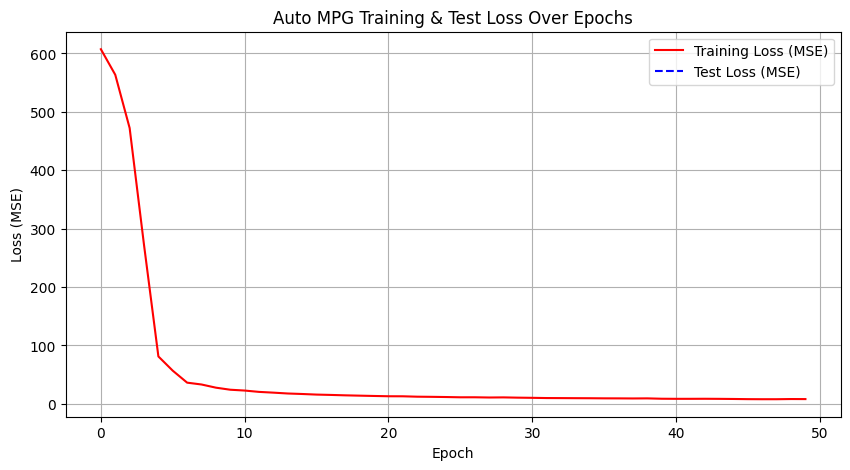

In [59]:
# 9. 결과 (Loss 그래프)
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (MSE)', color='red')
plt.plot(test_losses, label='Test Loss (MSE)', color='blue', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Auto MPG Training & Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()